# 2) pyGIMLi SRT manager

Next up, we want to get to know pyGIMLi's capabilities for refraction seismic data, accessible through in `pygimli.physics.traveltime`.

This package contains **tools, modelling operators, and managers** for refraction seismic data, supplying you with tools to **load, visualize, process and invert** your SRT field data.

This notebook should provide an **overview of the most basic operations** to help you process your own field data. 
To ensure the learning outcomes, we will provide a data set in case you do not have any own data on hand. 

**But we encourage you to process your own data during this workshop!**

In [1]:
# We import pyGIMLi and the traveltime module.

import matplotlib.pyplot as plt
import pygimli as pg
import pygimli.physics.traveltime as tt
import numpy as np

## 1.1 Data import and visualization

In [2]:
data = pg.load('../data/SRT_P2_coords.sgt')
data.showInfos()

Sensors: 90, Data: 1256
SensorIdx: g s  Data: err t valid 


(<Axes: xlabel='s', ylabel='g'>, <matplotlib.colorbar.Colorbar at 0x1337b84a0>)

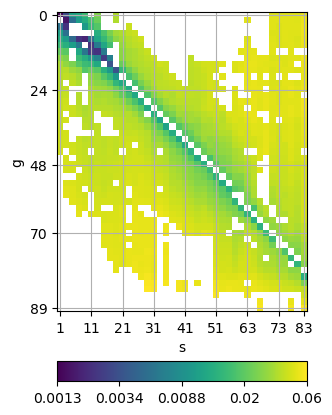

In [3]:
data.show()

## 1.2 Visualization of first picks and traveltime data

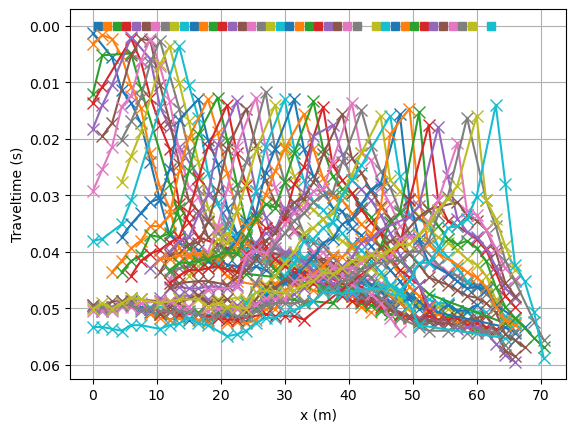

In [4]:
fig, ax = plt.subplots()
lines = tt.drawFirstPicks(ax, data)

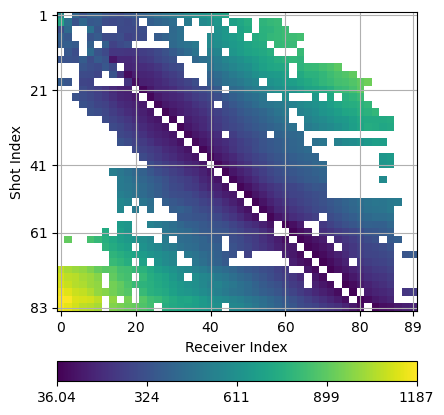

In [5]:
mgr = tt.TravelTimeManager(data)

# Alternatively, one can plot a matrix plot of apparent velocities which is the
# more general function also making sense for crosshole data.

ax, cbar = mgr.showData()

## 1.3 Inversion

In [6]:
mgr.createMesh(paraMaxCellSize=1.25, paraDepth=25)
mgr.invert()

19/09/26 - 13:21:47 - pyGIMLi - INFO - Found 1 regions.
19/09/26 - 13:21:47 - pyGIMLi - INFO - Creating forward mesh from region infos.
19/09/26 - 13:21:47 - pyGIMLi - INFO - Creating refined mesh (secnodes: 2) to solve forward task.
19/09/26 - 13:21:47 - pyGIMLi - INFO - Create gradient starting model. 500: 5000


3301 [111.06480515825895,...,1424.2249097914112]

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x163861c10>)

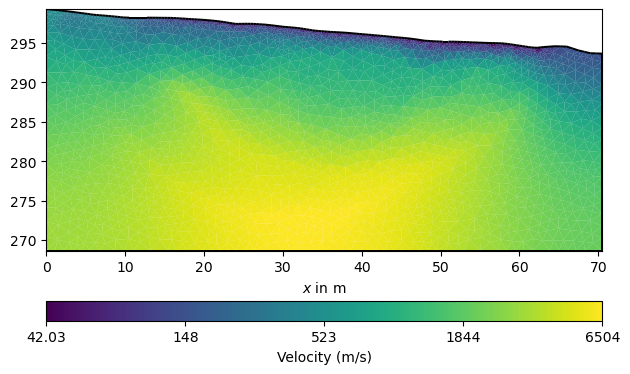

In [7]:
mgr.showResult()

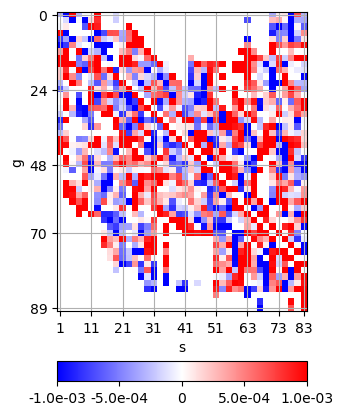

In [8]:
mgr.showMisfit()

(<Axes: xlabel='$x$ in m'>, <matplotlib.colorbar.Colorbar at 0x163e3ae40>)

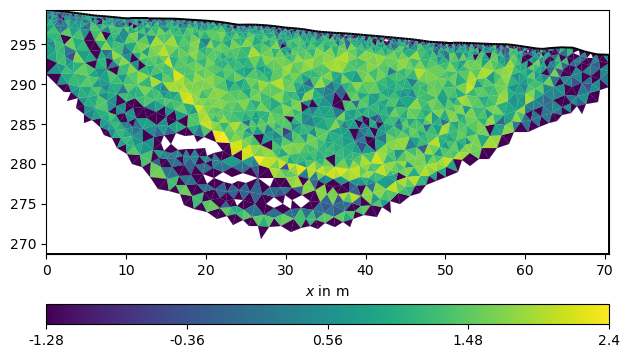

In [10]:
mgr.showCoverage()

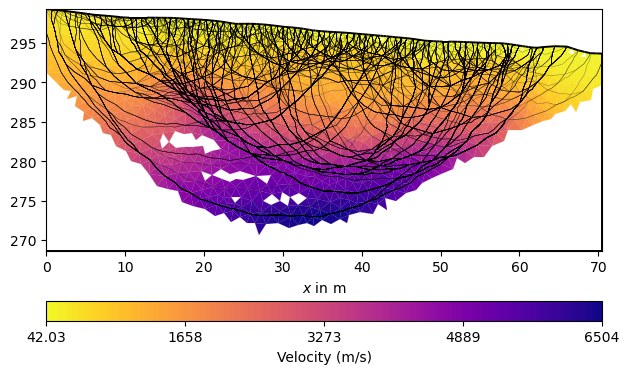

In [13]:
ax, cbar = mgr.showResult(logScale=False, cMap="plasma_r",
                          coverage=mgr.standardizedCoverage())
rays = mgr.drawRayPaths(ax=ax, color="k", lw=0.3, alpha=0.5)

In [ ]:
#mgr.saveResult()